# Importing Libraries & Loading Clean Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv("../clean_data/hotel_booking_cleaned.csv")

# EDA

In [3]:
df['is_canceled'].value_counts()

is_canceled
0    75166
1    44223
Name: count, dtype: int64

In [4]:
df['is_canceled'].value_counts(normalize=True)*100

is_canceled
0    62.958899
1    37.041101
Name: proportion, dtype: float64

## Cancellation Rate

In [5]:
(df['is_canceled'].mean()) * 100

np.float64(37.04110093894747)

## Repeat Guest Rate

In [6]:
(df['is_repeated_guest'].mean()) * 100

np.float64(3.1912487750127734)

## Revenue Lost From Cancellation

In [7]:
cancellation_revenue_loss= (df[df['is_canceled']==1]['revenue'].sum())

print(cancellation_revenue_loss)

16721837.120000001


## Dynamic Pricing Analysis

In [8]:
# Average ADR

df['adr'].mean()

np.float64(101.78674417241118)

In [26]:
# Revenue by month

monthly_revenue= df.groupby('arrival_date_month')['adr'].sum()
monthly_revenue.sort_values(ascending=False)

arrival_date_month
August       1944327.60
July         1605263.03
May          1281628.83
June         1276277.11
April        1113122.58
September    1103861.80
October       981063.09
March         784776.45
February      593661.80
December      549700.54
November      501362.97
January       417171.80
Name: adr, dtype: float64

In [10]:
# ADR by Hotel Type

df.groupby('hotel')['adr'].mean()

hotel
City Hotel      105.237722
Resort Hotel     94.952930
Name: adr, dtype: float64

## Customer Retention Analysis

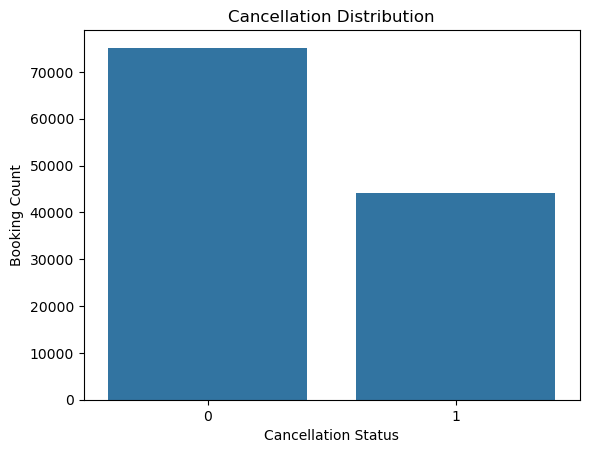

In [11]:
# cancellation rate distribution

sns.countplot(x='is_canceled', data=df)

plt.title("Cancellation Distribution")
plt.xlabel("Cancellation Status")
plt.ylabel("Booking Count")

plt.show()

### Note:

A significant portion of hotel bookings are canceled, indicating that customer churn is a major operational challenge for the hospitality business. This highlights the need for predictive cancellation models and proactive customer retention strategies.

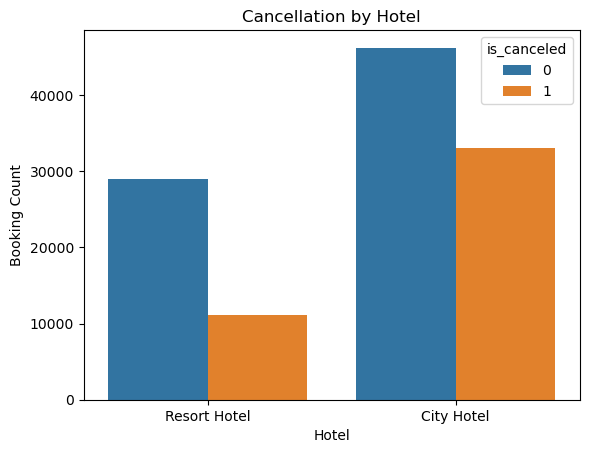

In [12]:
# cancellation as per hotel

sns.countplot(x='hotel', hue='is_canceled', data=df)

plt.title("Cancellation by Hotel")
plt.xlabel("Hotel")
plt.ylabel("Booking Count")

plt.show()


### Note: 

City hotels experience a significantly higher cancellation rate compared to resort hotels, which suggests that urban travelers may have more flexible or uncertain travel plans than leisure-focused resort customers.

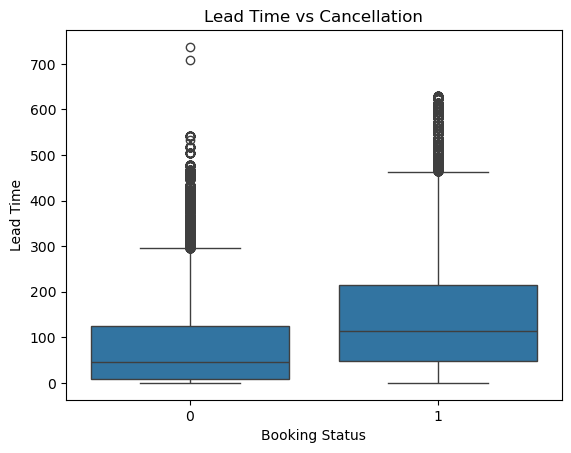

In [13]:
# lead time affect (lead time vs cancellation)

sns.boxplot(x='is_canceled', y='lead_time', data=df)

plt.title("Lead Time vs Cancellation")

plt.xlabel("Booking Status")
plt.ylabel("Lead Time")

plt.show()

### Note:
Bookings with longer lead times show higher cancellation tendencies, indicating that customers who book far in advance are more likely to change or cancel their travel plans.

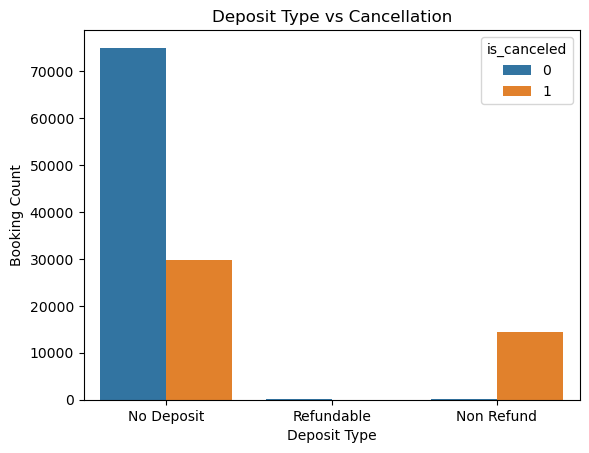

In [14]:
# Deposit Type vs cancellation

sns.countplot(x='deposit_type', hue='is_canceled', data=df)

plt.title("Deposit Type vs Cancellation")

plt.xlabel("Deposit Type")
plt.ylabel("Booking Count")

plt.show()

### Note:
Bookings without deposits show substantially higher cancellation rates, suggesting that upfront payment commitments reduce customer churn risk.

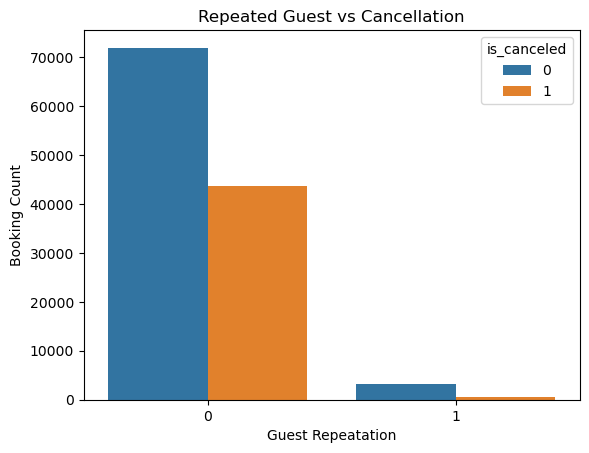

In [15]:
# Repeated guest vs cancellation

sns.countplot(x='is_repeated_guest', hue='is_canceled', data=df)

plt.title("Repeated Guest vs Cancellation")

plt.xlabel("Guest Repeatation")
plt.ylabel("Booking Count")
plt.show()

### Note:
Repeated guests demonstrate lower cancellation behavior compared to first-time customers, indicating stronger loyalty and more predictable booking behavior among returning customers.

## Dynamic Pricing Analysis

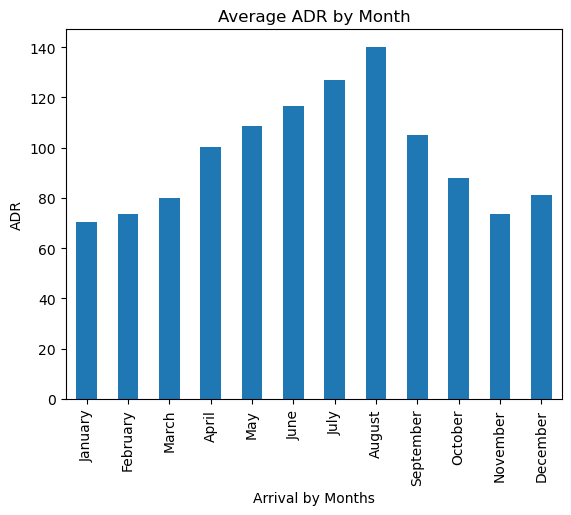

In [16]:
# Avg ADR by month

month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_adr= (
    df.groupby('arrival_date_month')['adr'].mean().reindex(month_order)
)

monthly_adr.plot(kind='bar')

plt.title("Average ADR by Month")

plt.xlabel("Arrival by Months")
plt.ylabel("ADR")
plt.show()

### Note:

During the high-demand travel months, particularly in the middle of the year, Average Daily Rates (ADR) tend to reach their peak levels. This pattern reflects the seasonal pricing behaviors observed in the hospitality industry, where increased demand coincides with popular vacation periods. That's why it shows a significant rise in rates.

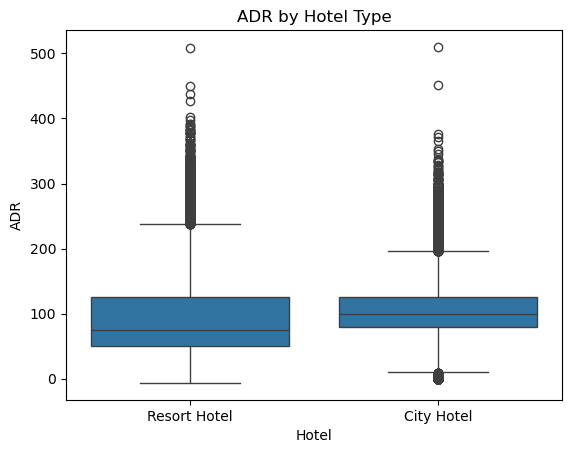

In [17]:
# ADR by hotel type

sns.boxplot(x='hotel', y='adr', data=df)

plt.title("ADR by Hotel Type")
plt.xlabel("Hotel")
plt.ylabel("ADR")

plt.show()

### Note:
- City hotels are maintaining higher ADR variability compared to resort hotels,
- This trend indicates that city hotels are likely to implement more dynamic pricing strategies, adjusting their rates in response to fluctuations in demand and changes in occupancy levels. Such responsive pricing practices allow them to capitalize on peak periods while remaining competitive during slower times.

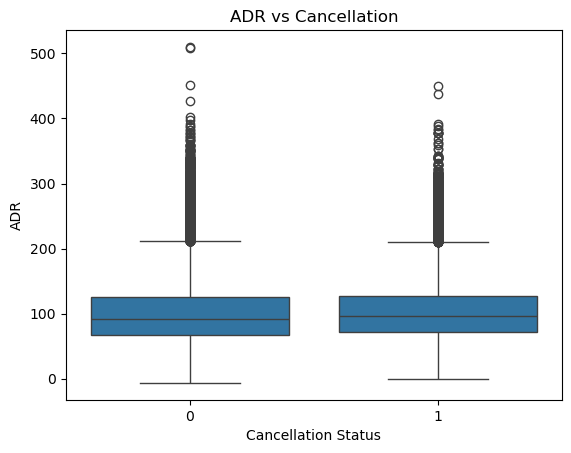

In [27]:
# ADR & cancellation 

sns.boxplot(x='is_canceled', y='adr', data=df)

plt.title("ADR vs Cancellation")

plt.xlabel("Cancellation Status")
plt.ylabel("ADR")

plt.show()

### Note:
Bookings with higher ADR values shows noticeable cancellation variation, suggesting that pricing sensitivity may influence customer cancellation decisions.

Average Daily Rate (ADR) has no significant impact on booking cancellations. Both completed (0) and canceled (1) bookings display nearly identical distributions, with a matching median ADR of approximately 95 and a shared core price range. Even high-ticket bookings (outliers up to 500) are tightly mirrored across both groups, proving that higher prices do not disproportionately trigger customer cancellations. Consequently, this indicates that pricing operates as a neutral factor, allowing hotels to confidently adjust rates dynamically without fear of escalating cancellation risks.

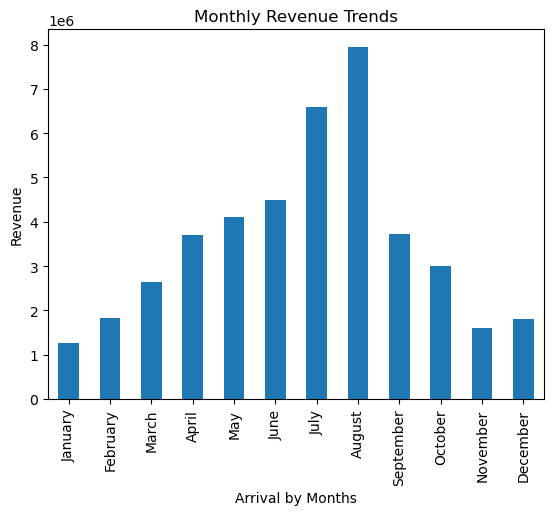

In [19]:
# revenue seasonality

month_order= [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_revenue = (
    df.groupby('arrival_date_month')['revenue'].sum().reindex(month_order)
)

monthly_revenue.plot(kind='bar')

plt.title("Monthly Revenue Trends")

plt.xlabel("Arrival by Months")
plt.ylabel("Revenue")

plt.show()

### Note:

Revenue demonstrates strong seasonality, with certain months (june, july & august) generating substantially higher booking revenue. This reflects demand concentration during peak travel periods.

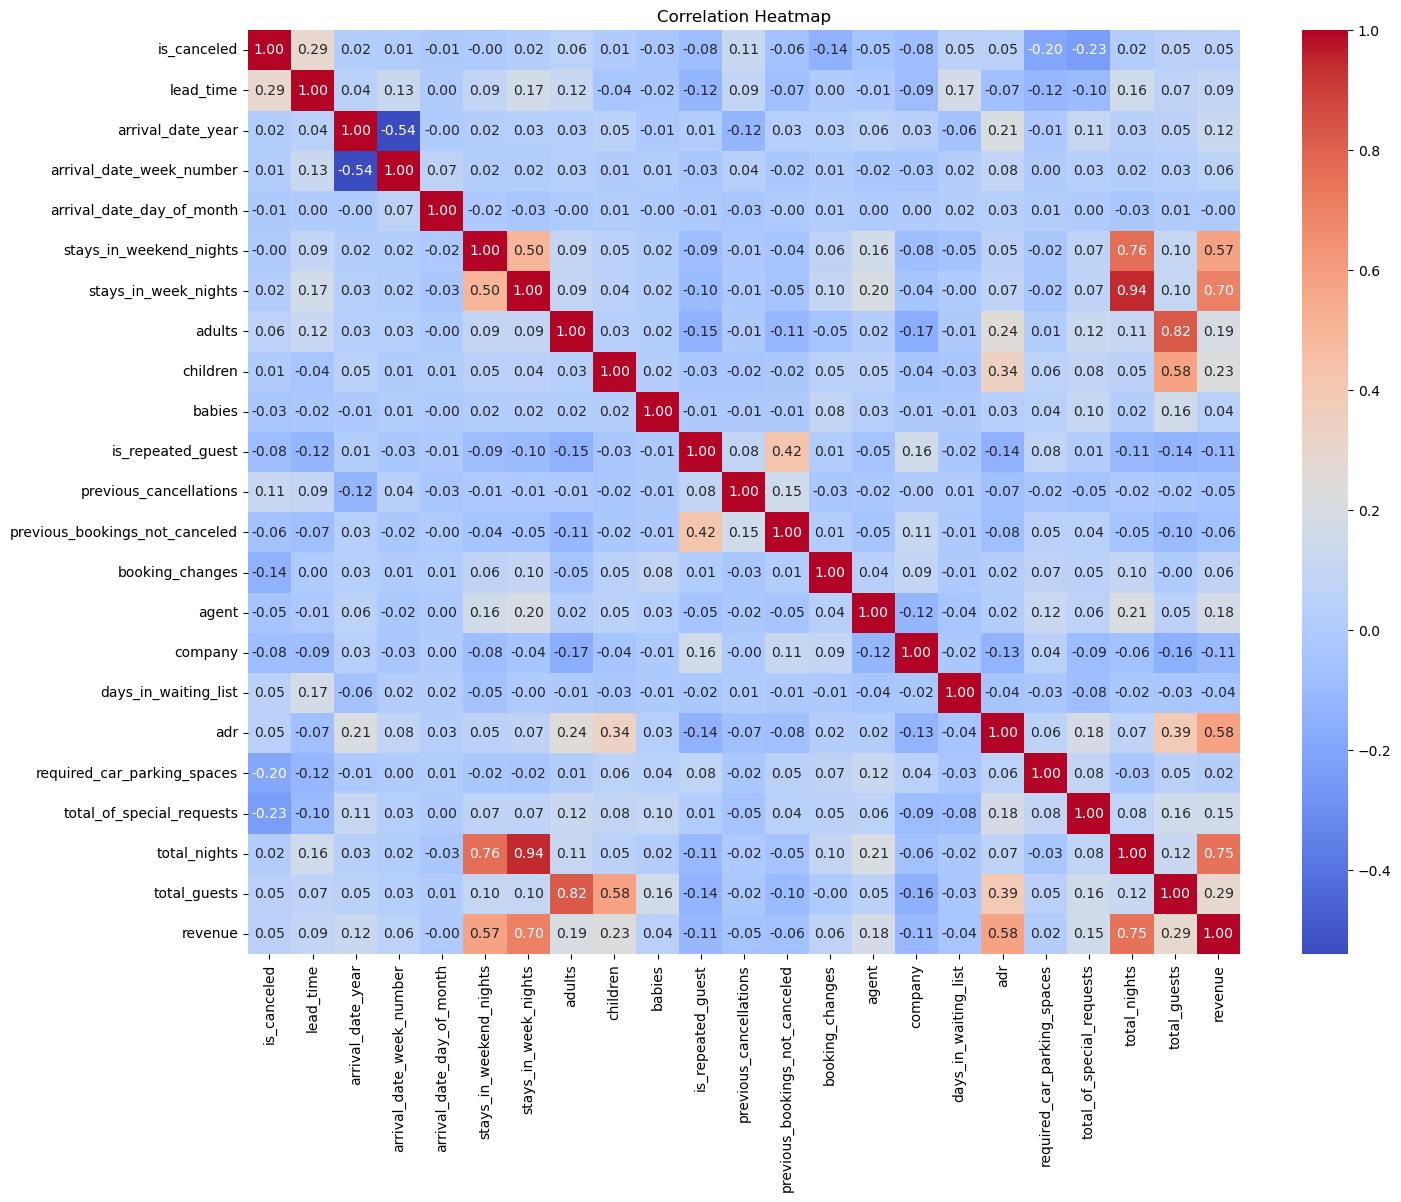

In [20]:
# Correlation Heatmap

plt.figure(figsize=(16,12))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

### Note:

The correlation analysis reveals that lead time, ADR, children, and total nights exhibit measurable relationships with booking cancellations and revenue generation, indicating their importance in predictive modeling.

## Customer Segmentation

In [21]:
# segment by customer type
df.groupby('customer_type')['is_canceled'].mean()

customer_type
Contract           0.309617
Group              0.102253
Transient          0.407457
Transient-Party    0.254299
Name: is_canceled, dtype: float64

### Note:

Different customer types display varying cancellation behavior, which suggests that targeted retention strategies can be designed for specific traveler segments.

In [22]:
# segment by market segment

df.groupby('market_segment')['is_canceled'].mean()

market_segment
Aviation         0.219409
Complementary    0.130552
Corporate        0.187347
Direct           0.153419
Groups           0.610620
Offline TA/TO    0.343133
Online TA        0.367211
Undefined        1.000000
Name: is_canceled, dtype: float64

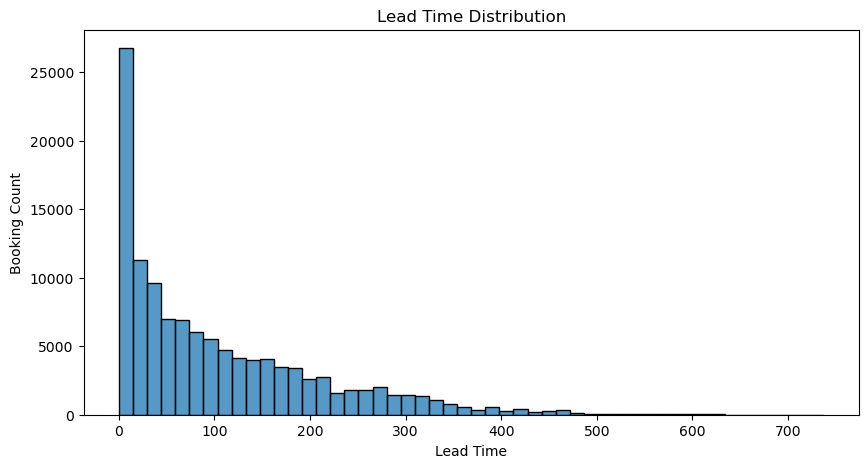

In [23]:
# Lead Time Distribution

plt.figure(figsize=(10,5))

sns.histplot(df['lead_time'], bins=50)

plt.title("Lead Time Distribution")
plt.xlabel("Lead Time")
plt.ylabel("Booking Count")

plt.show()

### Note:

Most bookings are made within shorter lead times, while a smaller proportion of customers book far in advance. This suggests that demand forecasting should account for short-term booking behavior.

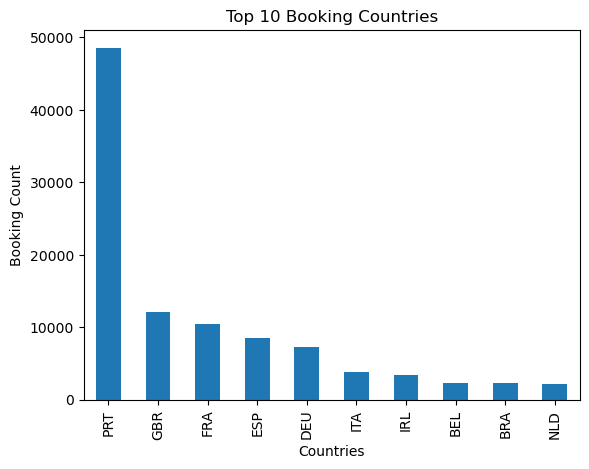

In [24]:
# Top Countires Analysis

top_countries = df['country'].value_counts().head(10)

top_countries.plot(kind='bar')

plt.title("Top 10 Booking Countries")

plt.ylabel("Booking Count")
plt.xlabel('Countries')

plt.show()

### Note:

A limited number of countries contribute the majority of hotel bookings, indicating key geographic markets that may deserve focused marketing and pricing strategies.


## Overall Conclusion

The exploratory data analysis revealed several critical patterns influencing customer retention and dynamic pricing within the hospitality sector.

The analysis identified that booking cancellations represent a significant operational challenge, particularly for city hotels and customers with longer lead times. Customers making bookings far in advance demonstrated a higher probability of cancellation, while repeated guests showed more stable booking behavior and lower cancellation tendencies. Additionally, bookings without deposits were associated with substantially higher cancellation rates, highlighting the importance of financial commitment in customer retention.

From a pricing perspective, Average Daily Rate (ADR) and revenue trends displayed strong seasonality across different months, confirming the presence of dynamic demand fluctuations throughout the year. Both resort and city hotels exhibited pricing variability and premium ADR outliers during peak demand periods, suggesting the use of dynamic pricing strategies based on occupancy and market conditions.

Customer segmentation analysis further demonstrated that cancellation behavior varies across customer types and market segments, indicating opportunities for targeted retention campaigns and personalized marketing strategies.

Overall, the analysis provides a strong analytical foundation for:
- predictive cancellation modeling,
- dynamic pricing optimization,
- seasonal revenue forecasting,
- and customer retention strategy development.

The cleaned dataset and EDA findings can now support machine learning models for cancellation prediction and future business intelligence dashboards in Power BI or other BI tool.